![910px-Man_being_arrested](910px-Man_being_arrested.jpg)

# Predicting Crime Hotspots: Can ML Help Allocate Police Resources?

In [67]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # for data visualisation purposes
from matplotlib.colors import ListedColormap # Everyone likes a splash of colour in the plots
from sklearn.tree import DecisionTreeClassifier ,plot_tree # Our model and a handy tool for visualising trees
from sklearn.metrics import accuracy_score

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('data2.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


## Dataset Description

This dataset contains crime data in Chicago, including various details such as:

- Crime Description
- ID
- Case number
- Arrested Yes or No
- date of arrest
- IUCR (Illinois universal crime reporting number)
- block
- primary type (I.e. Theft, Battery, Sex Offence, etc)
- Description
- Domestic
- District number, and long/lat

### Potential Uses

This dataset is suitable for a variety of analytical tasks, including but not limited to:

- **Predictive Modeling**: Building models to predict future crime occurrences based on historical data.
- **Trend Analysis**: Analyzing trends over time to understand how crime rates and types have changed.
- **Visualization**: Creating visual representations to better understand patterns and distributions in crime data. 


In [68]:
train_file_path = 'chicago_crime.csv'

# Create a new Pandas DataFrame with our training data
df_2024 = pd.read_csv("chicagocrime_2024.csv")
df_2025 = pd.read_csv("chicagocrime_2025.csv")

# Combine them vertically (axis=0 means row-wise)
df = pd.concat([df_2024, df_2025], axis=0)

#titanic_test_data.columns
df.describe(include='all')
#titanic_train_data.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
count,3.009390e+05,300939,300939,300939,300939,300939,300939,299803,300939,300939,300939.000000,300939.000000,300939.000000,300936.000000,300939,3.007990e+05,3.007990e+05,300939.000000,300939,300799.000000,300799.000000,300799
unique,NaN,300906,152406,29758,344,31,322,130,2,2,NaN,NaN,NaN,NaN,26,NaN,NaN,NaN,503,NaN,NaN,136160
top,NaN,JH327052,01/01/2024 12:00:00 AM,001XX N STATE ST,0486,THEFT,SIMPLE,STREET,False,False,NaN,NaN,NaN,NaN,06,NaN,NaN,NaN,12/21/2024 03:40:46 PM,NaN,NaN,POINT (-87.741528537 41.754592961)
freq,NaN,3,128,846,23873,70376,36693,80439,257954,245336,NaN,NaN,NaN,NaN,71406,NaN,NaN,NaN,242674,NaN,NaN,390
mean,1.352314e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1155.780185,11.328179,23.174700,36.235615,NaN,1.165281e+06,1.887656e+06,2024.143521,NaN,41.847311,-87.668948,NaN
std,6.461966e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,709.460158,7.089570,13.940208,21.596396,NaN,1.618460e+04,3.154934e+04,0.350604,NaN,0.086755,0.058934,NaN
min,2.793200e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.000000,1.000000,1.000000,1.000000,NaN,1.092647e+06,1.813897e+06,2024.000000,NaN,41.644590,-87.934567,NaN
25%,1.344089e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,533.000000,5.000000,10.000000,22.000000,NaN,1.153969e+06,1.860508e+06,2024.000000,NaN,41.772599,-87.710137,NaN
50%,1.355260e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1034.000000,10.000000,23.000000,32.000000,NaN,1.167148e+06,1.894301e+06,2024.000000,NaN,41.865662,-87.661846,NaN
75%,1.366389e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1732.000000,17.000000,34.000000,53.000000,NaN,1.176649e+06,1.910374e+06,2024.000000,NaN,41.909877,-87.627288,NaN


In [69]:
#drop null values
df.dropna(subset=['Longitude', 'Latitude', 'Location'], inplace=True)
#Drop data that is useless for us
df.drop(columns=['Updated On', 'Year', 'X Coordinate', 'Y Coordinate', 'FBI Code', 'ID', 'Case Number', 'IUCR'])


,Date,Block,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,Latitude,Longitude,Location
0,12/31/2024 11:58:00 PM,014XX E 68TH ST,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,332,3,5,43.0,41.771470,-87.590742,POINT (-87.59074212 41.771470188)
1,12/31/2024 11:56:00 PM,047XX S DR MARTIN LUTHER KING JR DR,CRIMINAL TRESPASS,TO RESIDENCE,APARTMENT,True,True,223,2,3,38.0,41.808501,-87.616563,POINT (-87.616562762 41.808500903)
2,12/31/2024 11:55:00 PM,077XX S CICERO AVE,BATTERY,"AGG. DOMESTIC BATTERY - HANDS, FISTS, FEET, SE...",HOTEL / MOTEL,False,True,834,8,18,70.0,41.752749,-87.741498,POINT (-87.741497836 41.752748627)
3,12/31/2024 11:53:00 PM,066XX S GREENWOOD AVE,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,321,3,20,42.0,41.774269,-87.599710,POINT (-87.599709962 41.774269351)
4,12/31/2024 11:50:00 PM,012XX N MENARD AVE,BATTERY,SIMPLE,SIDEWALK,False,False,2531,25,29,25.0,41.902858,-87.770537,POINT (-87.770536741 41.902858242)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43186,01/01/2025 12:00:00 AM,029XX W 36TH ST,BURGLARY,BURGLARY FROM MOTOR VEHICLE,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,911,9,12,58.0,41.828189,-87.698829,POINT (-87.698828692 41.828189214)
43187,01/01/2025 12:00:00 AM,036XX S WELLS ST,BURGLARY,UNLAWFUL ENTRY,APARTMENT,False,False,915,9,3,34.0,41.828622,-87.632659,POINT (-87.632658693 41.82862242)
43188,01/01/2025 12:00:00 AM,038XX W EDDY ST,THEFT,THEFT FROM MOTOR VEHICLE,RESIDENCE,False,False,1732,17,30,21.0,41.945518,-87.723317,POINT (-87.723316697 41.945517618)
43189,01/01/2025 12:00:00 AM,006XX N LAKE SHORE DR,BATTERY,DOMESTIC BATTERY SIMPLE,HOTEL / MOTEL,False,True,1834,18,2,8.0,41.893893,-87.615128,POINT (-87.615127644 41.893893173)


There's a lot of unique data, especially for crimes and the descriptions. To fix this, I will use a combination of cleaning unique or weird data, then grouping similar.

In [70]:
df.describe()
#BEFORE CLEANING
PT_U = len(pd.unique(df['Primary Type']))
D_U = len(pd.unique(df['Description']))
LOC_U = len(pd.unique(df['Location Description']))
print(f"BEFORE CLEANING: \n Primary type unique: {PT_U}\n Description unique: {D_U}\n Location unique: {LOC_U}")
#theres 300 k data we need to clean
#let's clean primary type and description also location descrption
df["Primary Type"] = df["Primary Type"].str.lower().str.strip()
df["Description"] = df["Description"].str.lower().str.strip()
df["Location Description"] = df["Location Description"].str.lower().str.strip()


PT_U = len(pd.unique(df['Primary Type']))
D_U = len(pd.unique(df['Description']))
LOC_U = len(pd.unique(df['Location Description']))
print(f"MID: Primary type unique: {PT_U}\n Description unique: {D_U}\n Location unique: {LOC_U}")
#kill unique values under 100

min_count = 100
crime_counts = df["Primary Type"].value_counts()
df["Primary Type"] = df["Primary Type"].apply(
    lambda x: x if pd.notna(x) and crime_counts[x] >= min_count else "other"
)
desc_counts = df["Description"].value_counts()
df["Description"] = df["Description"].apply(
    lambda x: x if pd.notna(x) and desc_counts[x] >= min_count else "other"
)
loc_counts = df["Location Description"].value_counts()
df["Location Description"] = df["Location Description"].apply(
    lambda x: x if pd.notna(x) and loc_counts[x] >= min_count else "other"
)

#let's see how many unique values
PT_U = len(pd.unique(df['Primary Type']))
D_U = len(pd.unique(df['Description']))
LOC_U = len(pd.unique(df['Location Description']))
print(f"\n AFTER: \n Primary type unique: {PT_U}\n Description unique: {D_U}\n Location unique: {LOC_U}")

BEFORE CLEANING: 
 Primary type unique: 31
 Description unique: 322
 Location unique: 131
MID: Primary type unique: 31
 Description unique: 322
 Location unique: 131

 AFTER: 
 Primary type unique: 26
 Description unique: 129
 Location unique: 73


Chicago crime is organized in Lat Long, coord, and Beat District Ward. Let's use Beat District Ward (BDW).

BDW is heirchy
District is area
Wards are 77 chicago community areas
Beat are the lowest level, typically consisting of a block or two. This will be the most useful, as beyond this it gets hard to map.
![area_district_beat_11x17](area_district_beat_11x17.pdf)

"Three to five beats make up a police sector, and three sectors make up a police district. The Chicago Police Department has 22 police districts. "

Here, I was wondering what the data looks like. Do some districts/beats have more theft, while others have violent crime? Or is the data generally spread out?

In [71]:
#crime types and other visualizations
import matplotlib.pyplot as mpl
import seaborn as sb
import geopandas as gpd
import folium
from shapely import wkt
import pandas as pd

## THIS IS THE BASE MAP NO NEED TO DISPLAY

#read the geometric 
df1 = pd.read_csv("chicagobeat.csv")


# Convert 'the_geom' column to geometric objects
df1['the_geom'] = df1['the_geom'].apply(wkt.loads)
df1 = gpd.GeoDataFrame(df1, geometry='the_geom')

# Set the coordinate reference system (CRS) to WGS 84 (epsg:4326)
df1 = df1.set_crs(epsg=4326)
print(df1.crs)

#CRS coordinate system translation
# Use WGS 84 (epsg:4326) as the geographic coordinate system

m = folium.Map(location=[41.881832, -87.623177], zoom_start=10, tiles="CartoDB positron")
for _, r in df1.iterrows():
    # Without simplifying the representation of each borough,
    # the map might not be displayed
    sim_geo = gpd.GeoSeries(r["the_geom"]).simplify(tolerance=0.001)
    geo_j = sim_geo.to_json()
    geo_j = folium.GeoJson(data=geo_j, style_function=lambda x: {"fillColor": "orange"})
    popup = folium.Popup(f"Beat: {r['BEAT_NUM']}")  # Shows on click
    popup.add_to(geo_j)
    geo_j.add_to(m)
#m

EPSG:4326


In [72]:
import matplotlib as mpl
import seaborn as sb
import folium
import geopandas as gpd

#most common crime

beat_crime = df.groupby('Beat')['Primary Type'].agg(lambda x: x.value_counts().idxmax()).reset_index()
beat_crime.columns = ['Beat', 'Most_Common_Crime']

# Merge the crime data with the beat geometry data
merged_df = df1.merge(beat_crime, left_on='BEAT_NUM', right_on='Beat')

# Create a color map for different crime types
crime_types = merged_df['Most_Common_Crime'].unique()
colors = sb.color_palette("hsv", len(crime_types))
color_map = dict(zip(crime_types, colors))

# Function to get color for each beat based on the most common crime
def get_color(crime_type):
    return mpl.colors.to_hex(color_map[crime_type])

# Create the map
m = folium.Map(location=[41.881832, -87.623177], zoom_start=10, tiles="CartoDB positron")

# Add beats to the map with colors based on the most common crime
for _, r in merged_df.iterrows():
    sim_geo = gpd.GeoSeries(r["the_geom"]).simplify(tolerance=0.001)
    geo_j = sim_geo.to_json()
    geo_j = folium.GeoJson(
        data=geo_j, 
        style_function=lambda x, crime_type=r['Most_Common_Crime']: {"fillColor": get_color(crime_type)}
    )
    popup = folium.Popup(f"Beat: {r['BEAT_NUM']}<br>Most Common Crime: {r['Most_Common_Crime']}")
    popup.add_to(geo_j)
    geo_j.add_to(m)

m

It seems that the most common are either Theft or Battery. I wonder why?????
Maybe let's see.
I also want to experiment one hot encoding versus label encoding
I did some research and for trees it might be better for label encoding (theft = 1, crime = 2, etc)

<Axes: xlabel='Count', ylabel='Crime Type'>

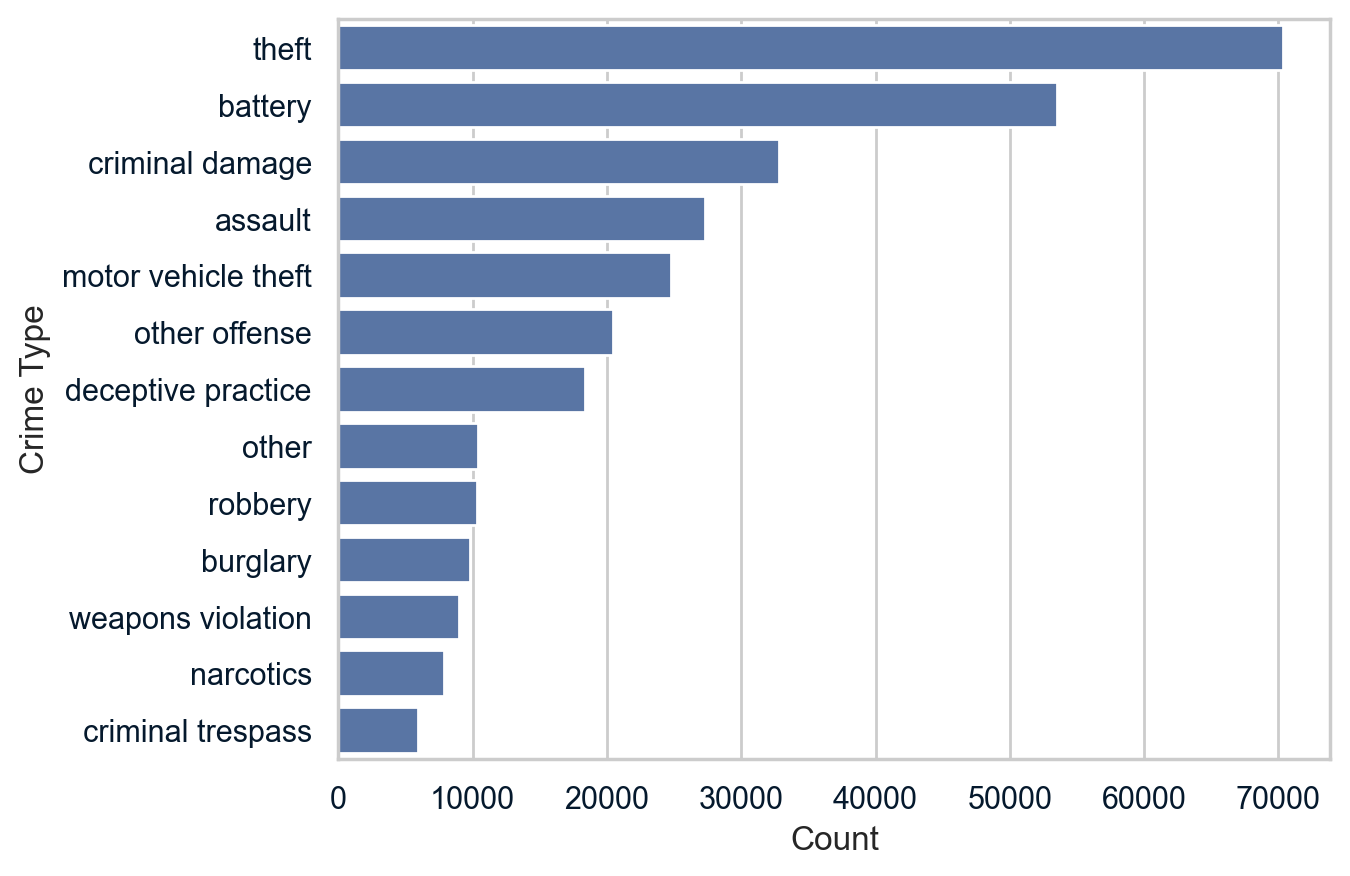

In [73]:
# Let's make some graphs
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

# Drop under like 2k
min_count = 2000
crime_counts = df["Primary Type"].value_counts()
df["Primary Type"] = df["Primary Type"].apply(
    lambda x: x if pd.notna(x) and crime_counts[x] >= min_count else "other"
)
desc_counts = df["Description"].value_counts()
df["Description"] = df["Description"].apply(
    lambda x: x if pd.notna(x) and desc_counts[x] >= min_count else "other"
)
loc_counts = df["Location Description"].value_counts()
df["Location Description"] = df["Location Description"].apply(
    lambda x: x if pd.notna(x) and loc_counts[x] >= min_count else "other"
)

# Get the counts of each crime type
max_counts = df['Primary Type'].value_counts().reset_index()
max_counts.columns = ['Crime Type', 'Count']

# Draw a scatter plot x = crime type, y = count
sns.barplot(x=max_counts['Count'], y=max_counts['Crime Type'])


In [74]:
#convert to datetime format
df['Date'] = pd.to_datetime(df['Date'])
print(df['Date'].head())

0   2024-12-31 23:58:00
1   2024-12-31 23:56:00
2   2024-12-31 23:55:00
3   2024-12-31 23:53:00
4   2024-12-31 23:50:00
Name: Date, dtype: datetime64[ns]


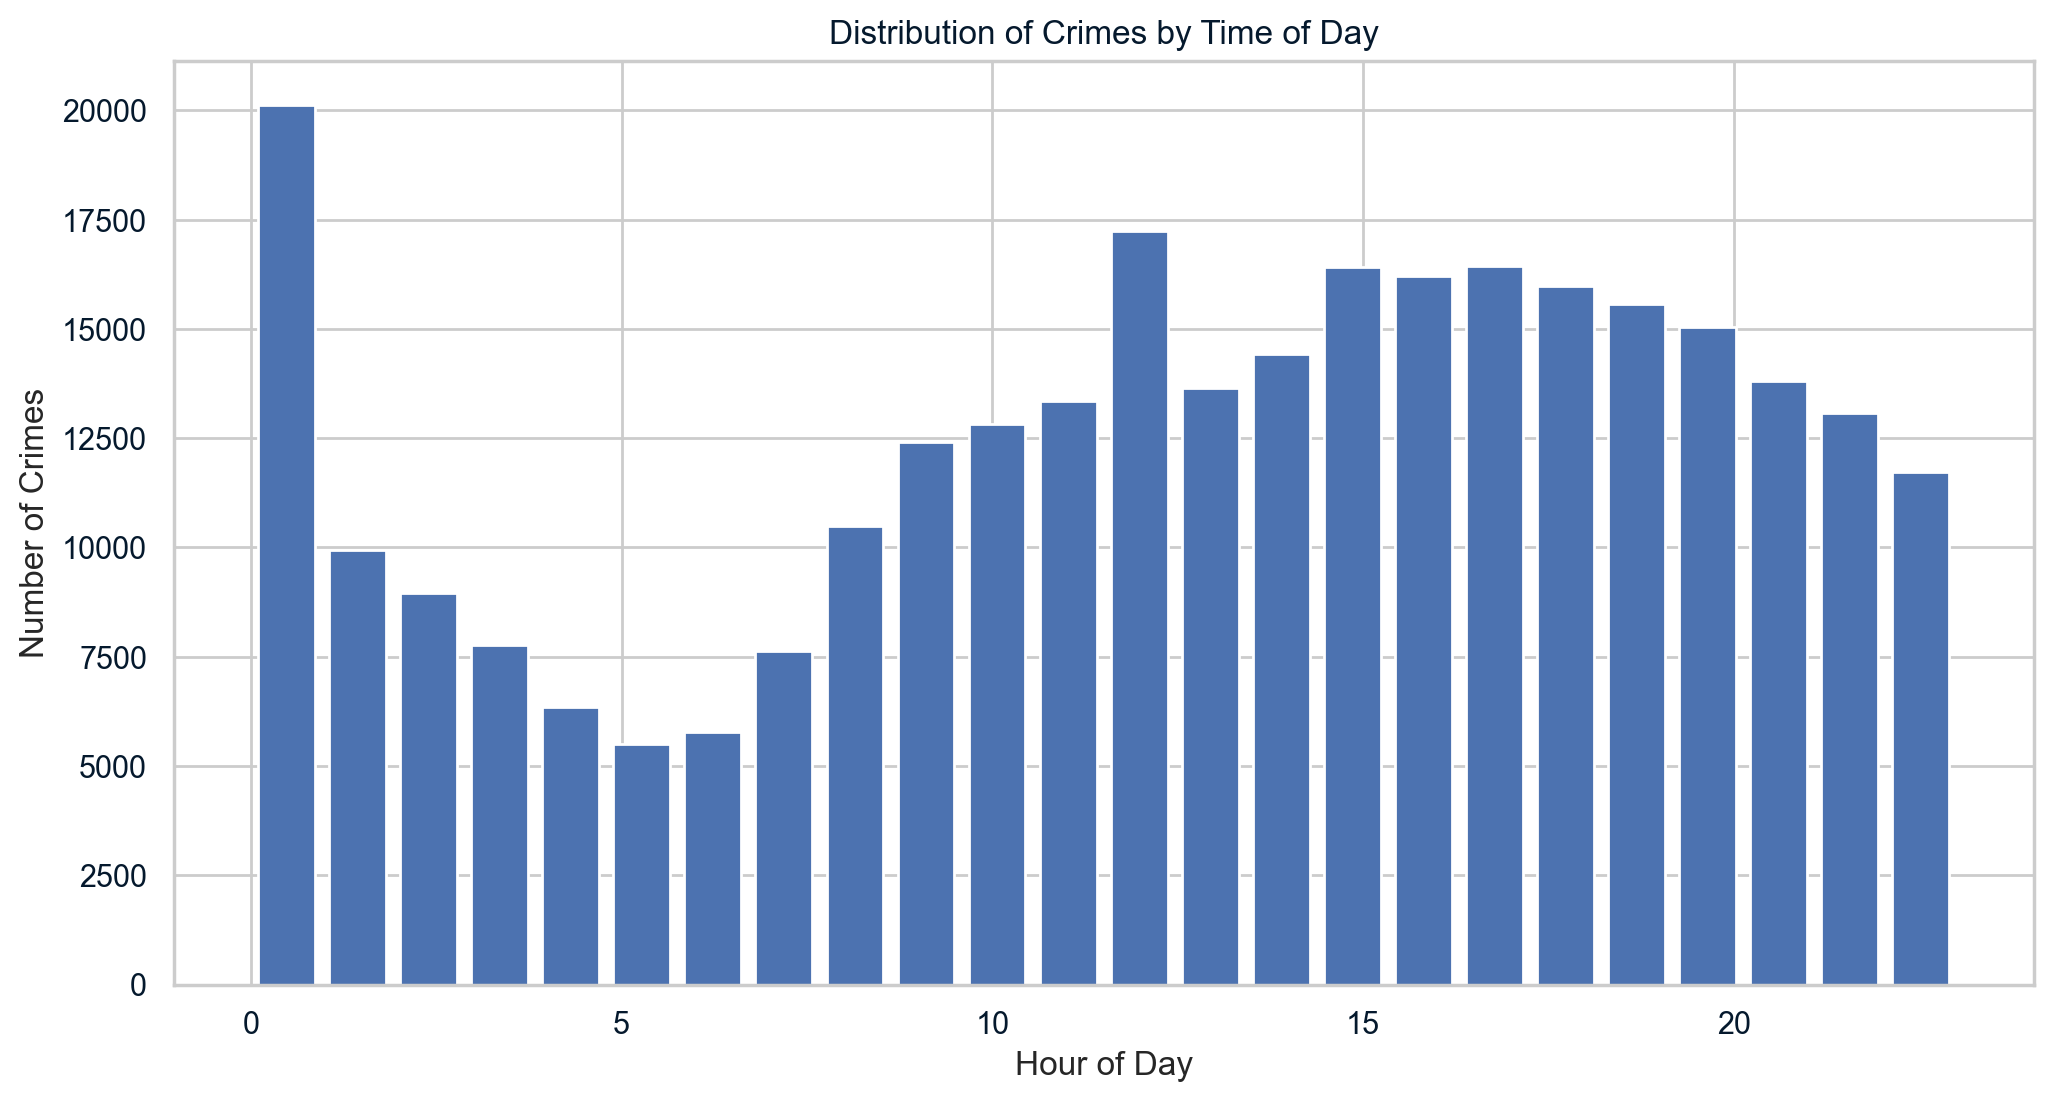

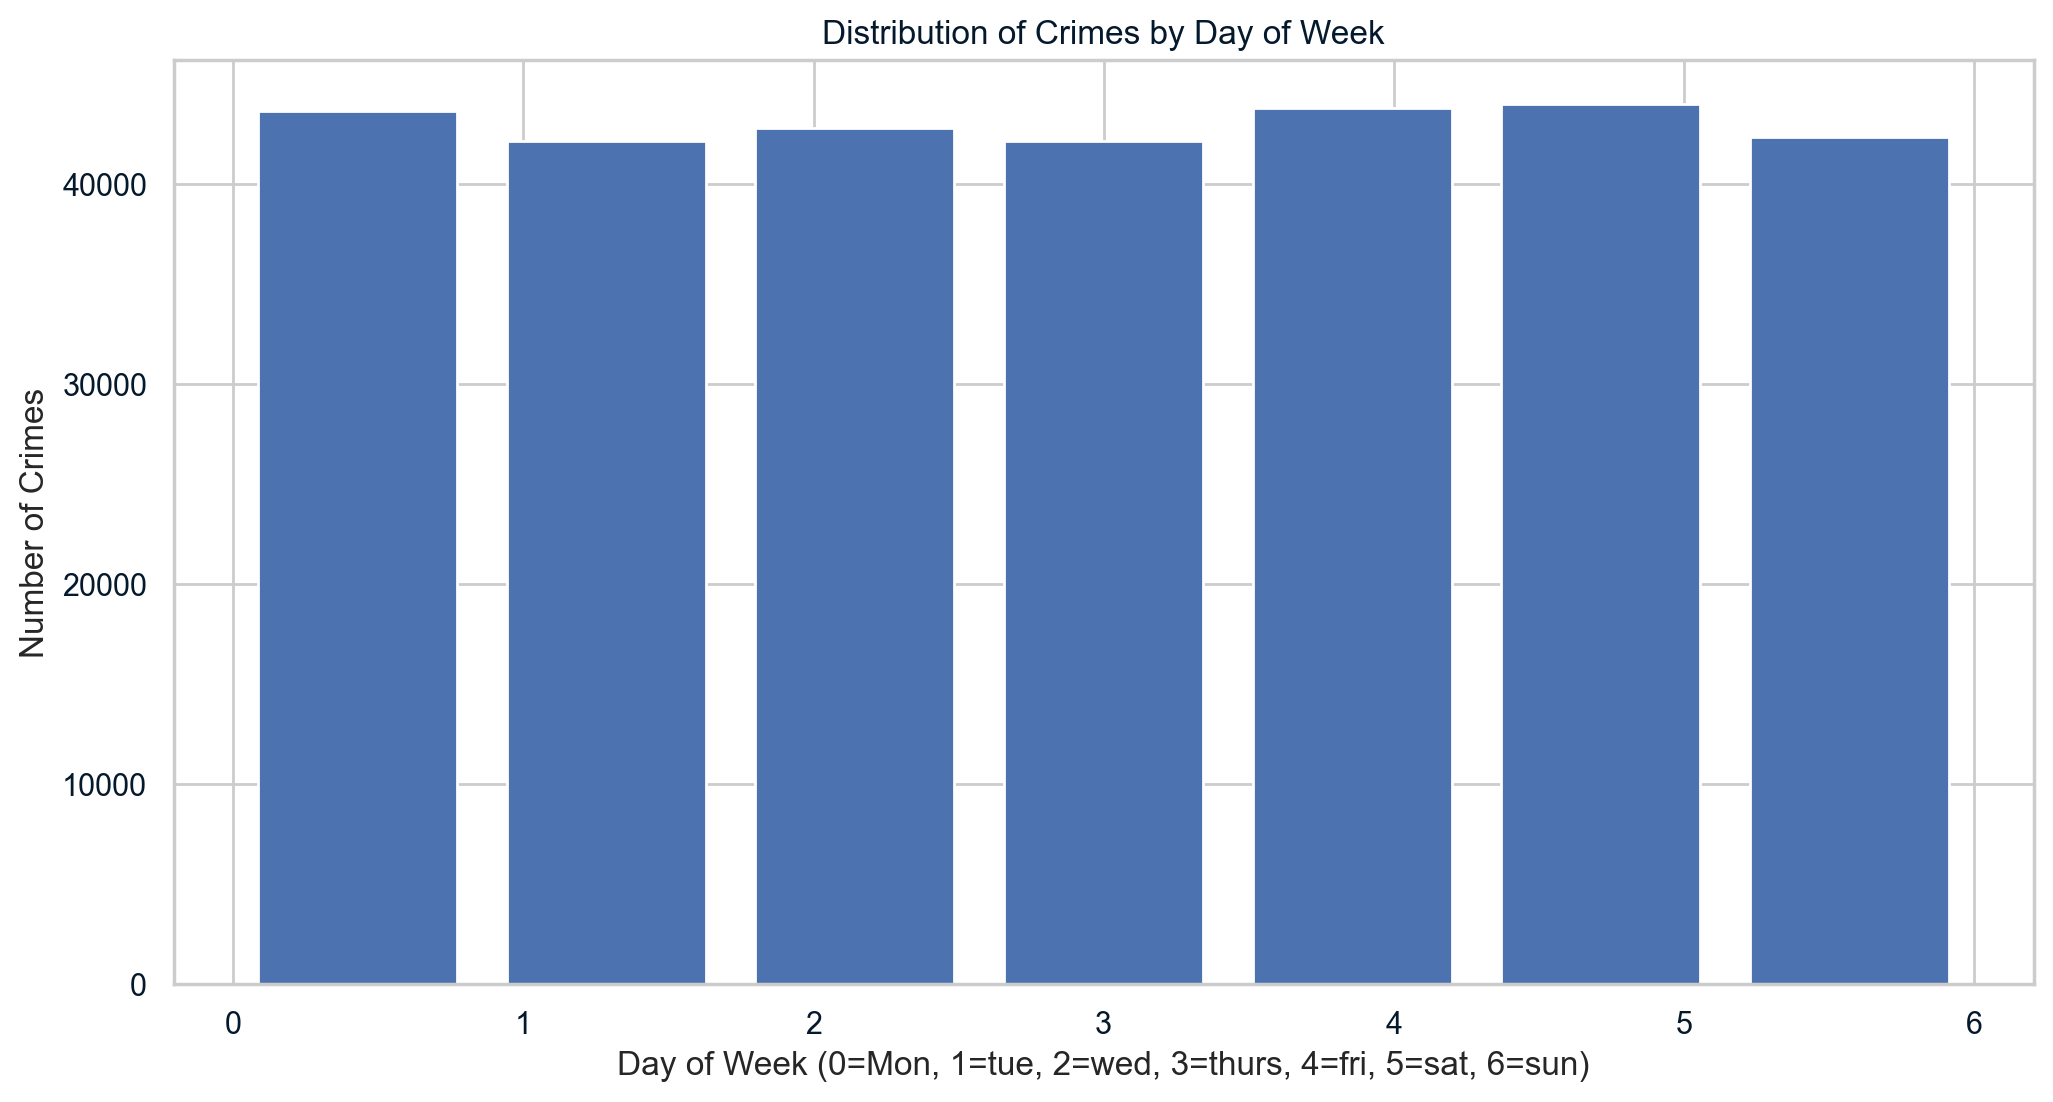

In [75]:

# Plot the distribution of crimes by time of day
plt.figure(figsize=(12, 6))
df['Date'].dt.hour.plot(kind='hist', bins=24, rwidth=0.8)
plt.title('Distribution of Crimes by Time of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Crimes')
plt.show()

# Plot the distribution of crimes by day of week
plt.figure(figsize=(12, 6))
df['Date'].dt.dayofweek.plot(kind='hist', bins=7, rwidth=0.8)
plt.title('Distribution of Crimes by Day of Week')
plt.xlabel('Day of Week (0=Mon, 1=tue, 2=wed, 3=thurs, 4=fri, 5=sat, 6=sun)')
plt.ylabel('Number of Crimes')
plt.show()

It seems that criminals most often work on monday, friday and sat. Even criminals on that monday grind! 

Crimes are also reported following daytime hours (lots during the day), but there are spikes on 12pm and 1am. This could be for many reasons, but I personally think it is because lunch break all the cops report the things they did during the day, and midnight could either be night shift or the database updates daily.

<Axes: xlabel='Count', ylabel='Desc'>

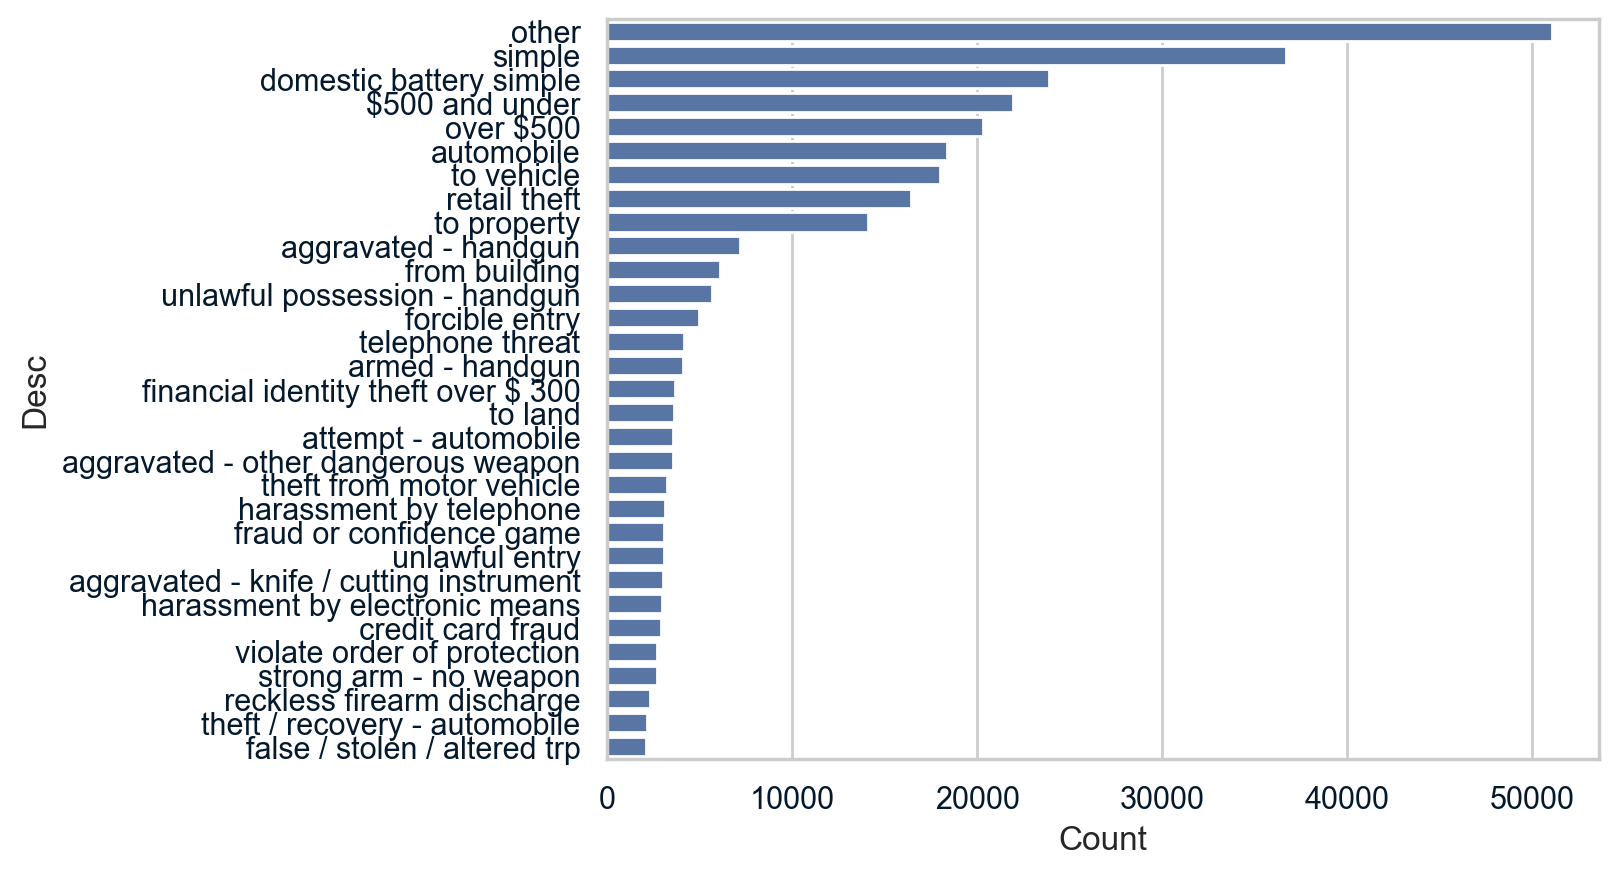

In [76]:
#fit code to set up and clean it
df.head()
new_data = df
#make new_data that is only the description and the counts
desc_counts = df['Description'].value_counts().reset_index()
desc_counts.columns = ['Desc', 'Count']
sns.barplot(x=desc_counts['Count'], y=desc_counts['Desc'])
#wonder if this is too skewed but itll be fine (its not too many)
#seems that too many are other, but there's nothing we can do. I think it is safest to keep as this info might help (quite a bit)





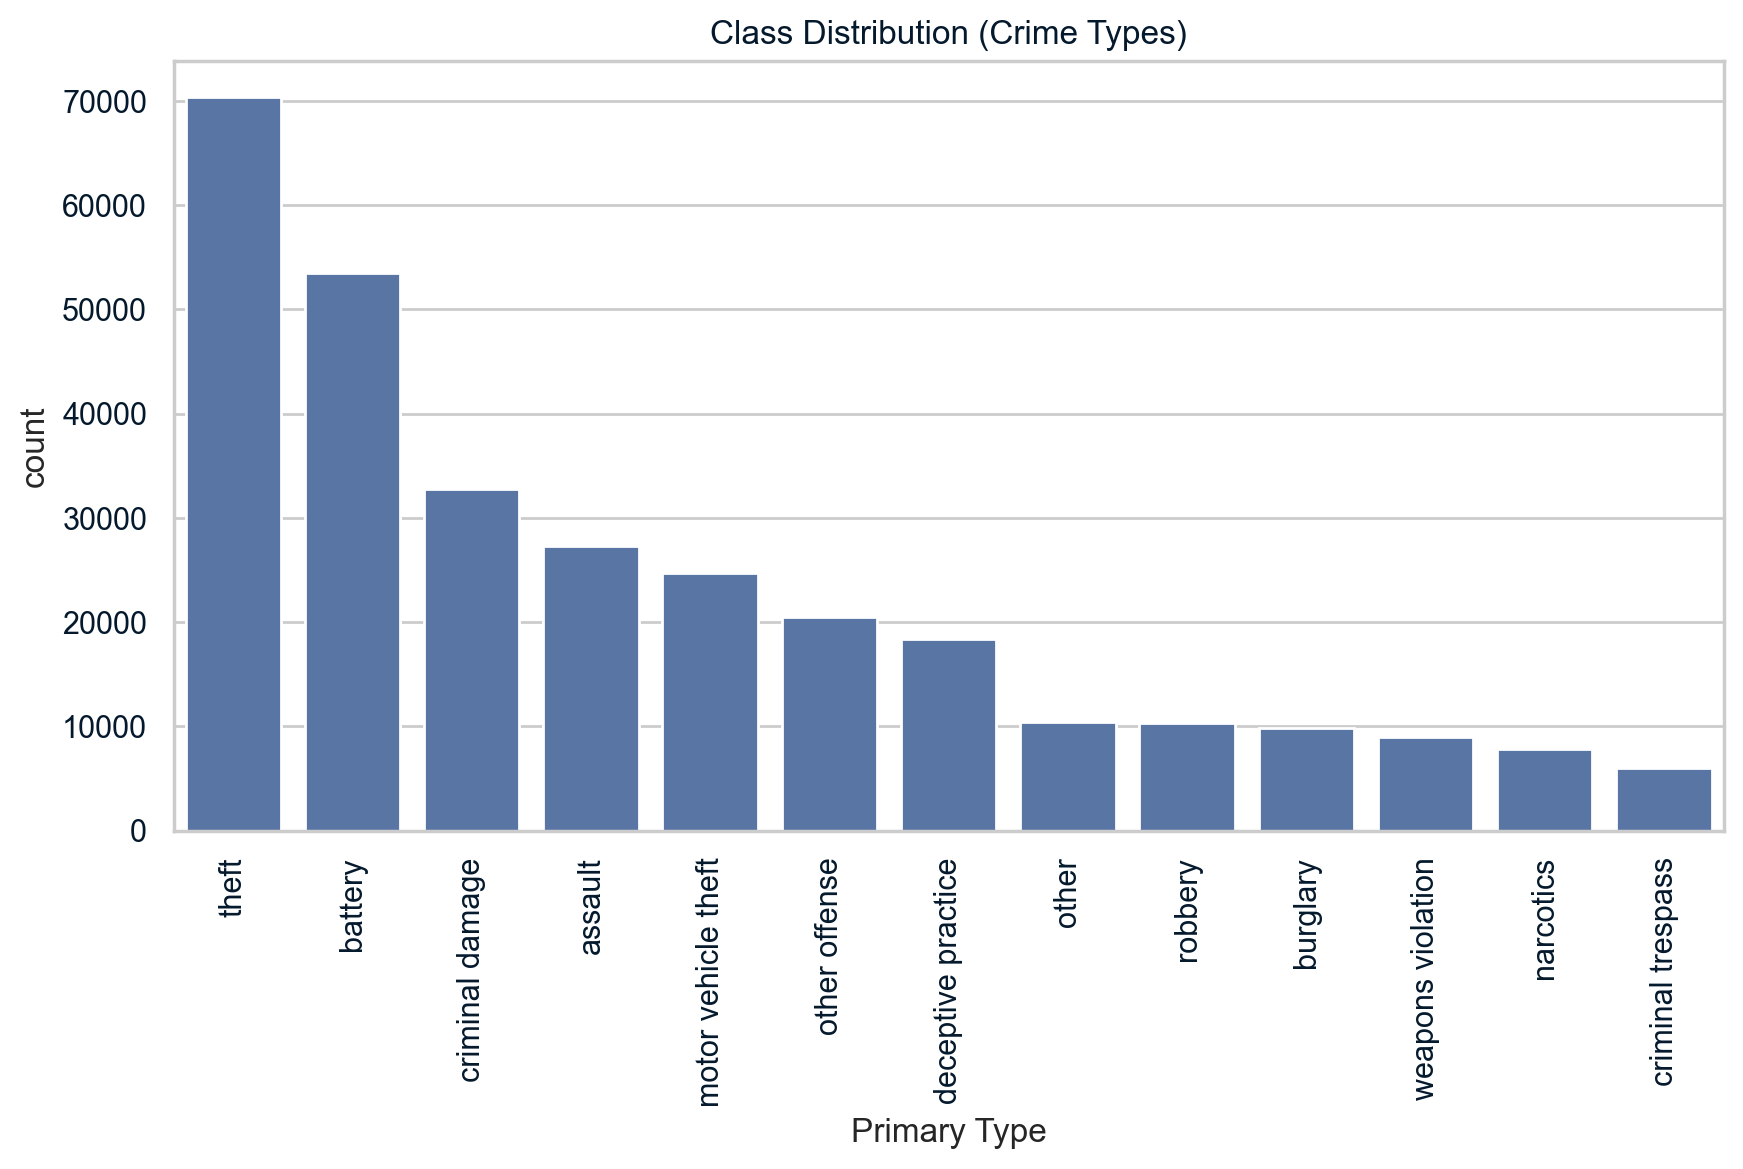

In [77]:

# Plot class distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='Primary Type', data=df, order=df['Primary Type'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Class Distribution (Crime Types)')
plt.show()

#just looking at data shape

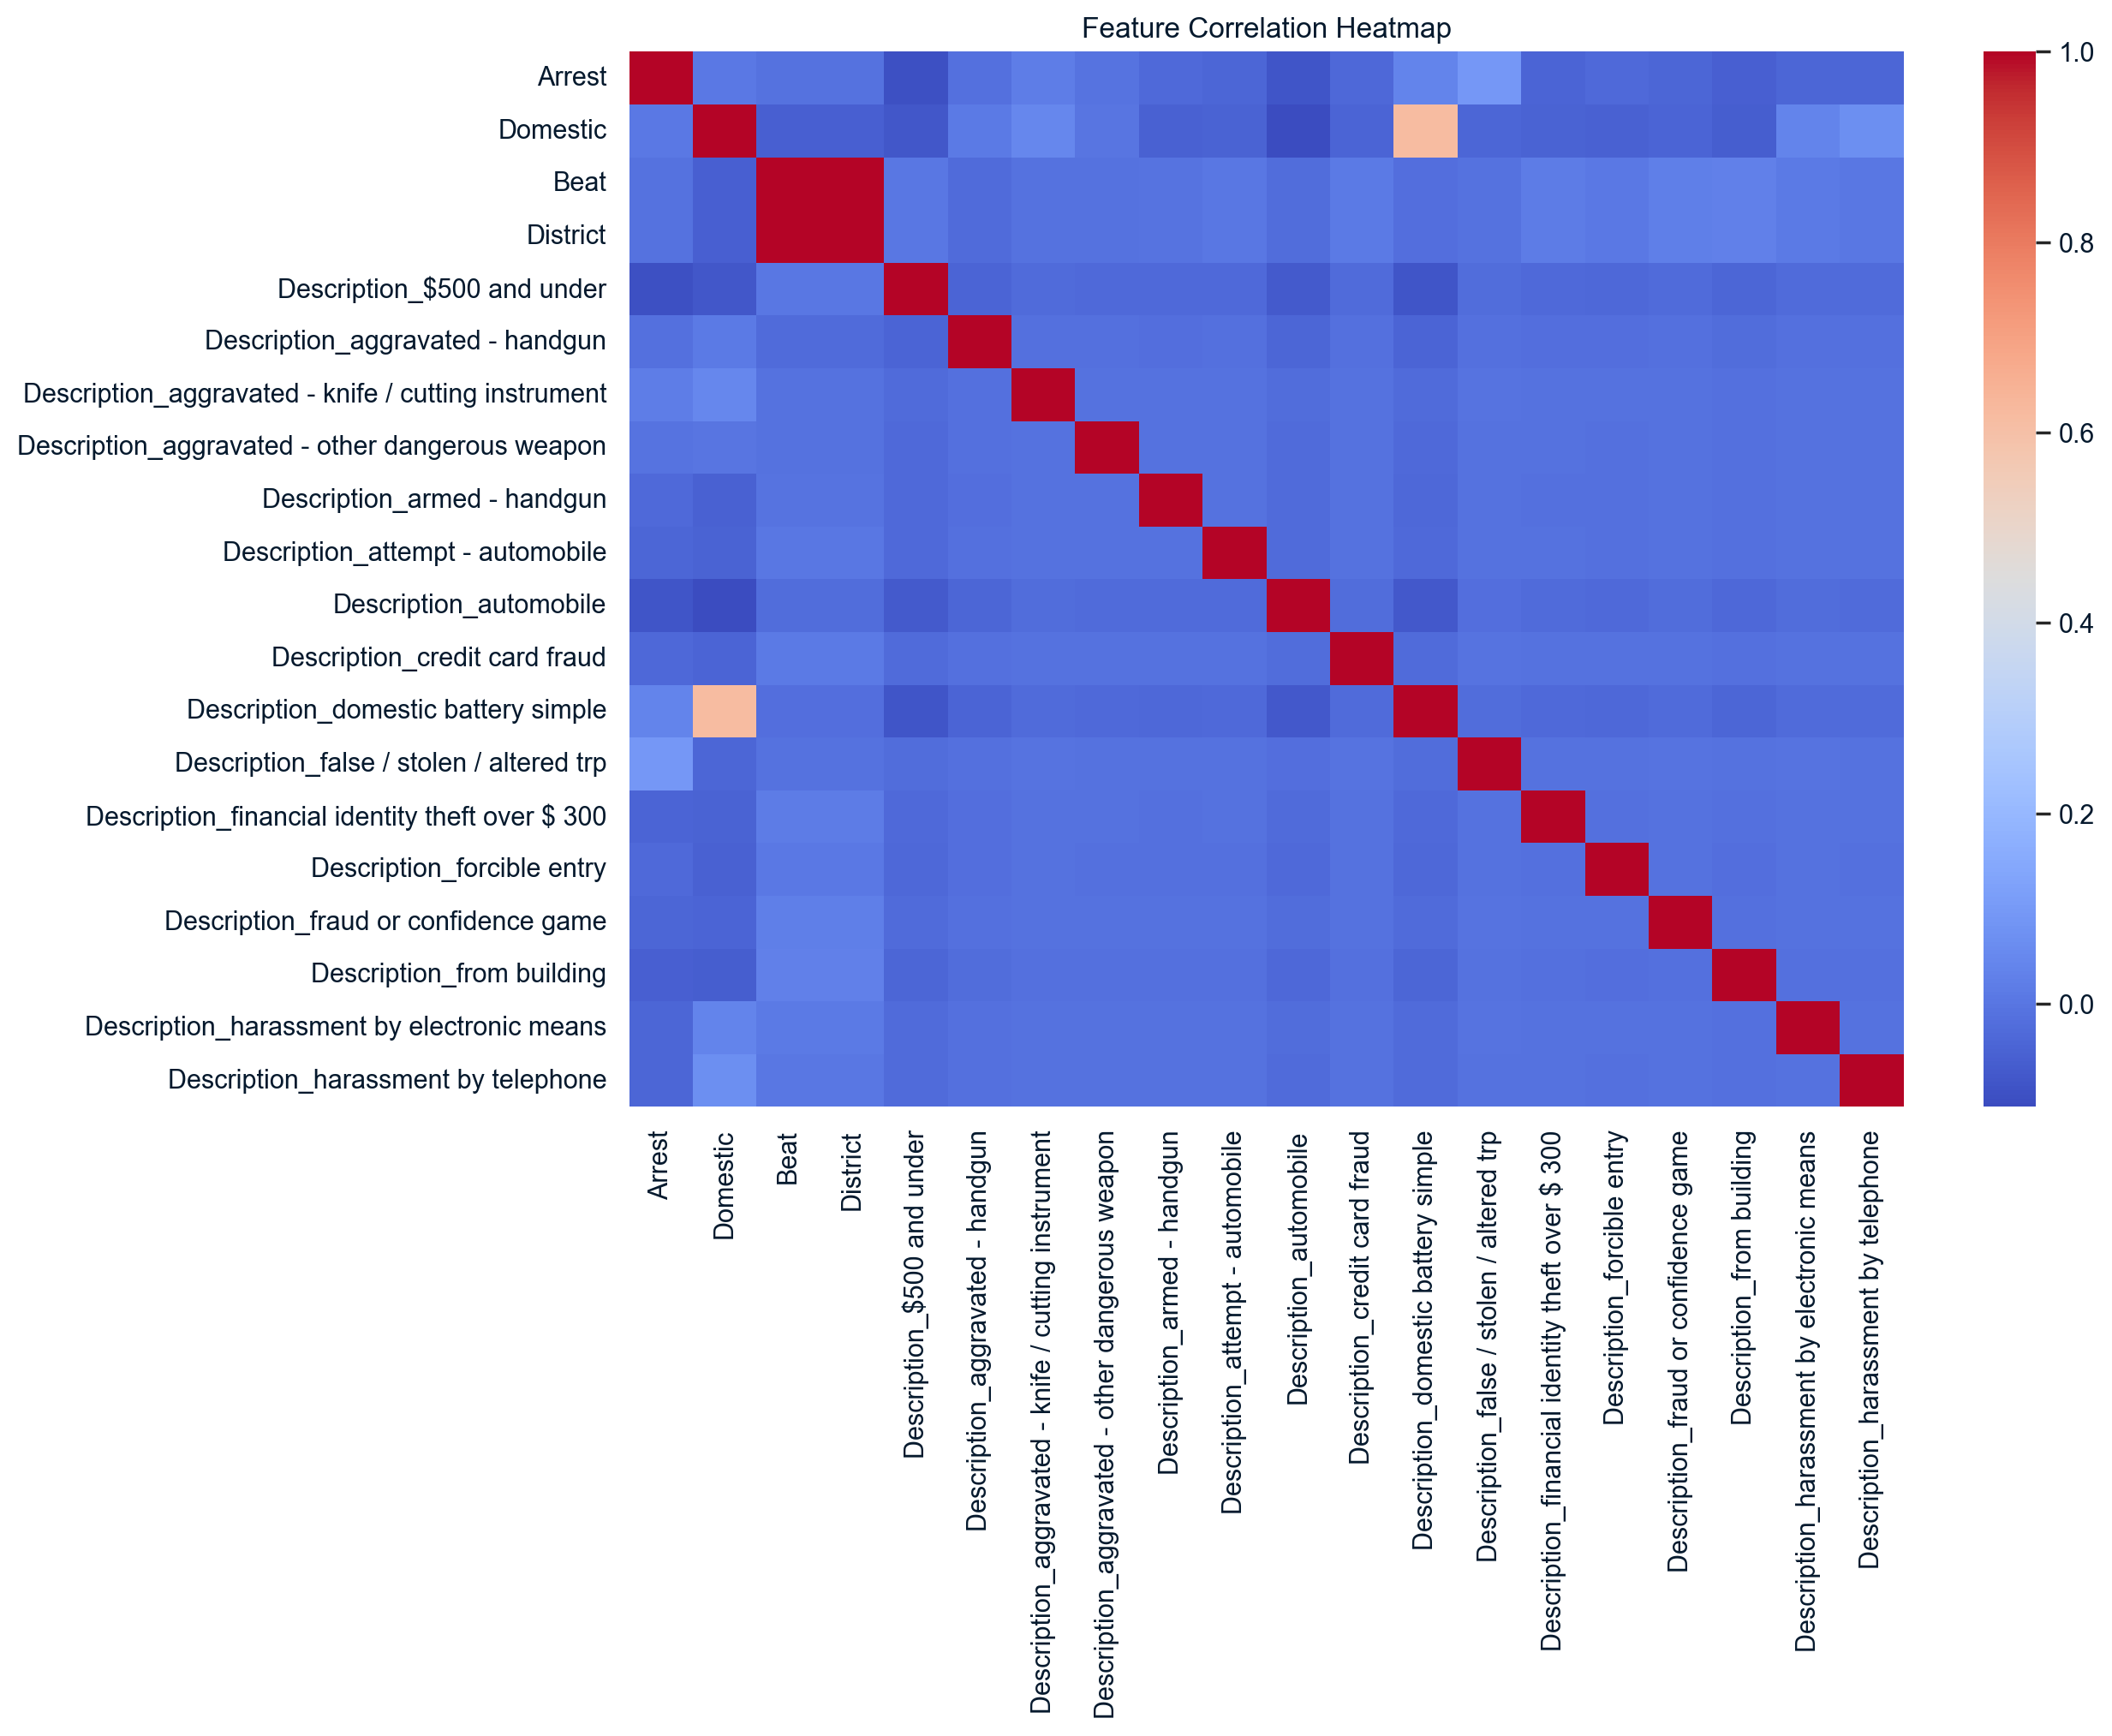

In [78]:
# cleaning so we look at the heatmap to check if its all the same

# Compute correlations (for numeric/one-hot features)
corr_matrix = train_X.corr()

# Plot heatmap (top 20 features)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix.iloc[:20, :20], cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()


let's use this data

I did some things to the data
1. One hot encoding:
   It is necessary because the model cannot use words, only can use numbers. Therefore, separating categorical data is required. The way it is done is in the following image:
   ![image1](https://i.imgur.com/mtimFxh.png)
2. Split data into training and valuation. X is the input, and Y is the thing you are trying to predict. I am predicting the primary type (crime type) using all the listed below X

X = 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District' - I use these features to predict the primary type
Y = Primary Type

In [79]:
X = df[['Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District']].copy()
#make copy to avoid interfering with old
X = pd.get_dummies(X)
#get dummies is one hot encoding
#turn categorical data into numbers

y= df[['Primary Type']].copy()

y = pd.get_dummies(y)
from sklearn.model_selection import train_test_split
train_X, val_X, train_y, val_y = train_test_split(X, y,random_state = 0)


In [80]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

dtc = DecisionTreeClassifier(random_state=1)

train_Xdt, train_ydt, val_Xdt, val_ydt = train_X, train_y, val_X, val_y #make copy of vars

dtc.fit(train_Xdt, train_ydt)

pred_y = dtc.predict(val_Xdt)
accuracy = metrics.accuracy_score(val_ydt, pred_y)
accuracy

# Let's plot the tree to see what it looks like!

#plt.figure(figsize = (20,10))
#plot_tree(dtc,feature_names=train_Xdt.columns,filled=True)
#plt.show()

#this took like 10 mins so don't run unless u need to 

0.7992553191489362

In [81]:

# Use a classifier random forest
from sklearn.ensemble import RandomForestClassifier
import sklearn.metrics as metrics
import pandas as pd

# Ensure that train_X and val_X do not contain datetime columns

print(train_X.shape, train_y.shape)

train_Xrf, train_yrf, val_Xrf, val_yrf = train_X, train_y, val_X, val_y #copy vars

random_forest = RandomForestClassifier(random_state=1, n_estimators=100)
random_forest.fit(train_Xrf, train_yrf)
pred_yrf = random_forest.predict(val_Xrf)
# Predict
accuracy = metrics.accuracy_score(val_yrf, pred_yrf)
print("Accuracy: ", accuracy)

(225599, 59) (225599, 13)
Accuracy:  0.8103058510638298


Decision tree classifier is a tree that classifies based on the input.
- uses rules like if input1 <= 200 and other input2 1<x<19... etc
- Random forest is like a 'forest' of these; it uses many, many descision trees to classify in parallel
- XG boost or Extreme Gradient Boosting uses Gradient Boosting. Gradient Boosting is just using lots of descsision trees
- Random Forest and XGBoost both use lots of descsion trees
- Main difference is XGboost does trees one after another, while forest does them in parallel

In [82]:
from xgboost import XGBClassifier
from sklearn import metrics
#use XG boost
xbclassifier = XGBClassifier(
    n_estimators=1000,           # use early_stopping_rounds to optimize
    early_stopping_rounds=10,    # stops training if no improvement
    random_state=1
)
train_Xxg, train_yxg, val_Xxg, val_yxg = train_X, train_y, val_X, val_y #make copy of vars

# Add eval_set parameter to include validation data
xbclassifier.fit(train_Xxg, train_yxg, eval_set=[(val_Xxg, val_yxg)], verbose=False)

pred_y = xbclassifier.predict(val_Xxg)
accuracy = metrics.accuracy_score(val_yxg, pred_y)
print("Accuracy: ", accuracy)

Accuracy:  0.8035372340425532


Random Forest: ~81% accuracy 
XG boost: ~80% accurdacy 
Descision Tree: ~79% accuracy

To measure accuracy, there are 2 sets of data (split off from the dataset after clean up): Train and Val (evaluation). 
- Train trains the model by giving answers and the inputs
- Val Evaluates the model by giving only inputs, and checking if the model got it correct. In this case, Random forest got about 81% of all the evaluation inputs correct, while XGboost got 80% correct.

I wonder if we can get better accuracy using a different model like a neural network



Neural networks come in many layers, but I will start then optimize the parameters if the base is not good. Each parameter adjusts different things.

![image](image.png)


In [83]:
#need to convert all bool into int for tensors 

#print(train_X.dtypes)  # Check feature columns


train_X = train_X.astype(int)  # Converts all booleans to 1/0
train_y = train_y.astype(int)  # Converts all booleans to 1/0
print(train_y.dtypes)  # Check target

Primary Type_assault                int64
Primary Type_battery                int64
Primary Type_burglary               int64
Primary Type_criminal damage        int64
Primary Type_criminal trespass      int64
Primary Type_deceptive practice     int64
Primary Type_motor vehicle theft    int64
Primary Type_narcotics              int64
Primary Type_other                  int64
Primary Type_other offense          int64
Primary Type_robbery                int64
Primary Type_theft                  int64
Primary Type_weapons violation      int64
dtype: object


In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



#this one doesent work -- run at your own rist
#its the baseline
#it was very slow then I added to it
'''
# Making a baseline model for starting point
model = Sequential([
    Dense(128, activation='relu', input_shape=(59,)),  # Input layer
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(13, activation='softmax')  # Output layer (13 classes)
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_X, train_y, validation_split=0.2, epochs=50, verbose=0)

# Convert history to DataFrame for Seaborn
history_df = pd.DataFrame(history.history)
history_df['epoch'] = history_df.index + 1

# Melt for Seaborn
melted_df = history_df.melt(id_vars='epoch', var_name='metric', value_name='value')

# Plot
#plt.figure(figsize=(12, 6))
#sns.lineplot(data=melted_df, x='epoch', y='value', hue='metric', style='metric', markers=True)
#plt.title('Training & Validation Metrics')
#plt.xlabel('Epoch')
#plt.ylabel('Value')
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.show()

#takes too long to make - uncomment if u want to see it
'''

2025-05-12 02:36:12.269241: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747017372.284245     343 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747017372.288786     343 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747017372.301403     343 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747017372.301420     343 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747017372.301423     343 computation_placer.cc:177] computation placer alr

"\n# Making a baseline model for starting point\nmodel = Sequential([\n    Dense(128, activation='relu', input_shape=(59,)),  # Input layer\n    BatchNormalization(),\n    Dropout(0.3),\n    Dense(64, activation='relu'),\n    Dropout(0.2),\n    Dense(13, activation='softmax')  # Output layer (13 classes)\n])\n\n# Compile the model\nmodel.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])\n\nhistory = model.fit(train_X, train_y, validation_split=0.2, epochs=50, verbose=0)\n\n# Convert history to DataFrame for Seaborn\nhistory_df = pd.DataFrame(history.history)\nhistory_df['epoch'] = history_df.index + 1\n\n# Melt for Seaborn\nmelted_df = history_df.melt(id_vars='epoch', var_name='metric', value_name='value')\n\n# Plot\n#plt.figure(figsize=(12, 6))\n#sns.lineplot(data=melted_df, x='epoch', y='value', hue='metric', style='metric', markers=True)\n#plt.title('Training & Validation Metrics')\n#plt.xlabel('Epoch')\n#plt.ylabel('Value')\n#plt.legend(bbox_to_anchor

In [85]:
#tune

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model = Sequential([
    Dense(256, activation='relu', input_shape=(59,)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(13, activation='softmax') 
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',  # Changed from 'sparse_categorical_crossentropy' to 'categorical_crossentropy'
    metrics=['accuracy']
)

#early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3)

# Assuming train_y is one-hot encoded
history = model.fit(train_X, train_y, epochs=50, batch_size=256,  validation_split=0.2, callbacks=[early_stop])

# Convert history to DataFrame for Seaborn
history_df = pd.DataFrame(history.history)
history_df['epoch'] = history_df.index + 1

# Melt for Seaborn
melted_df = history_df.melt(id_vars='epoch', var_name='metric', value_name='value')



Epoch 1/50
705/705 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.3006 - loss: 2.1383 - val_accuracy: 0.3030 - val_loss: 2.9030
Epoch 2/50
705/705 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6663 - loss: 0.9092 - val_accuracy: 0.7315 - val_loss: 0.7492
Epoch 3/50
705/705 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7478 - loss: 0.6718 - val_accuracy: 0.7923 - val_loss: 0.5629
Epoch 4/50
705/705 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7605 - loss: 0.6354 - val_accuracy: 0.7014 - val_loss: 0.7739
Epoch 5/50
705/705 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7771 - loss: 0.5836 - val_accuracy: 0.8025 - val_loss: 0.4595
Epoch 6/50
705/705 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7845 - loss: 0.5620 - val_accuracy: 0.8029 - val_loss: 0.4915
Epoch 7/50
705/705 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7952 - loss: 0.5373 - val_accuracy: 0.8132 - val_loss: 0.4660
Epoch 8/50
705/705 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7960 - loss: 0.5388 - val_accuracy: 0.

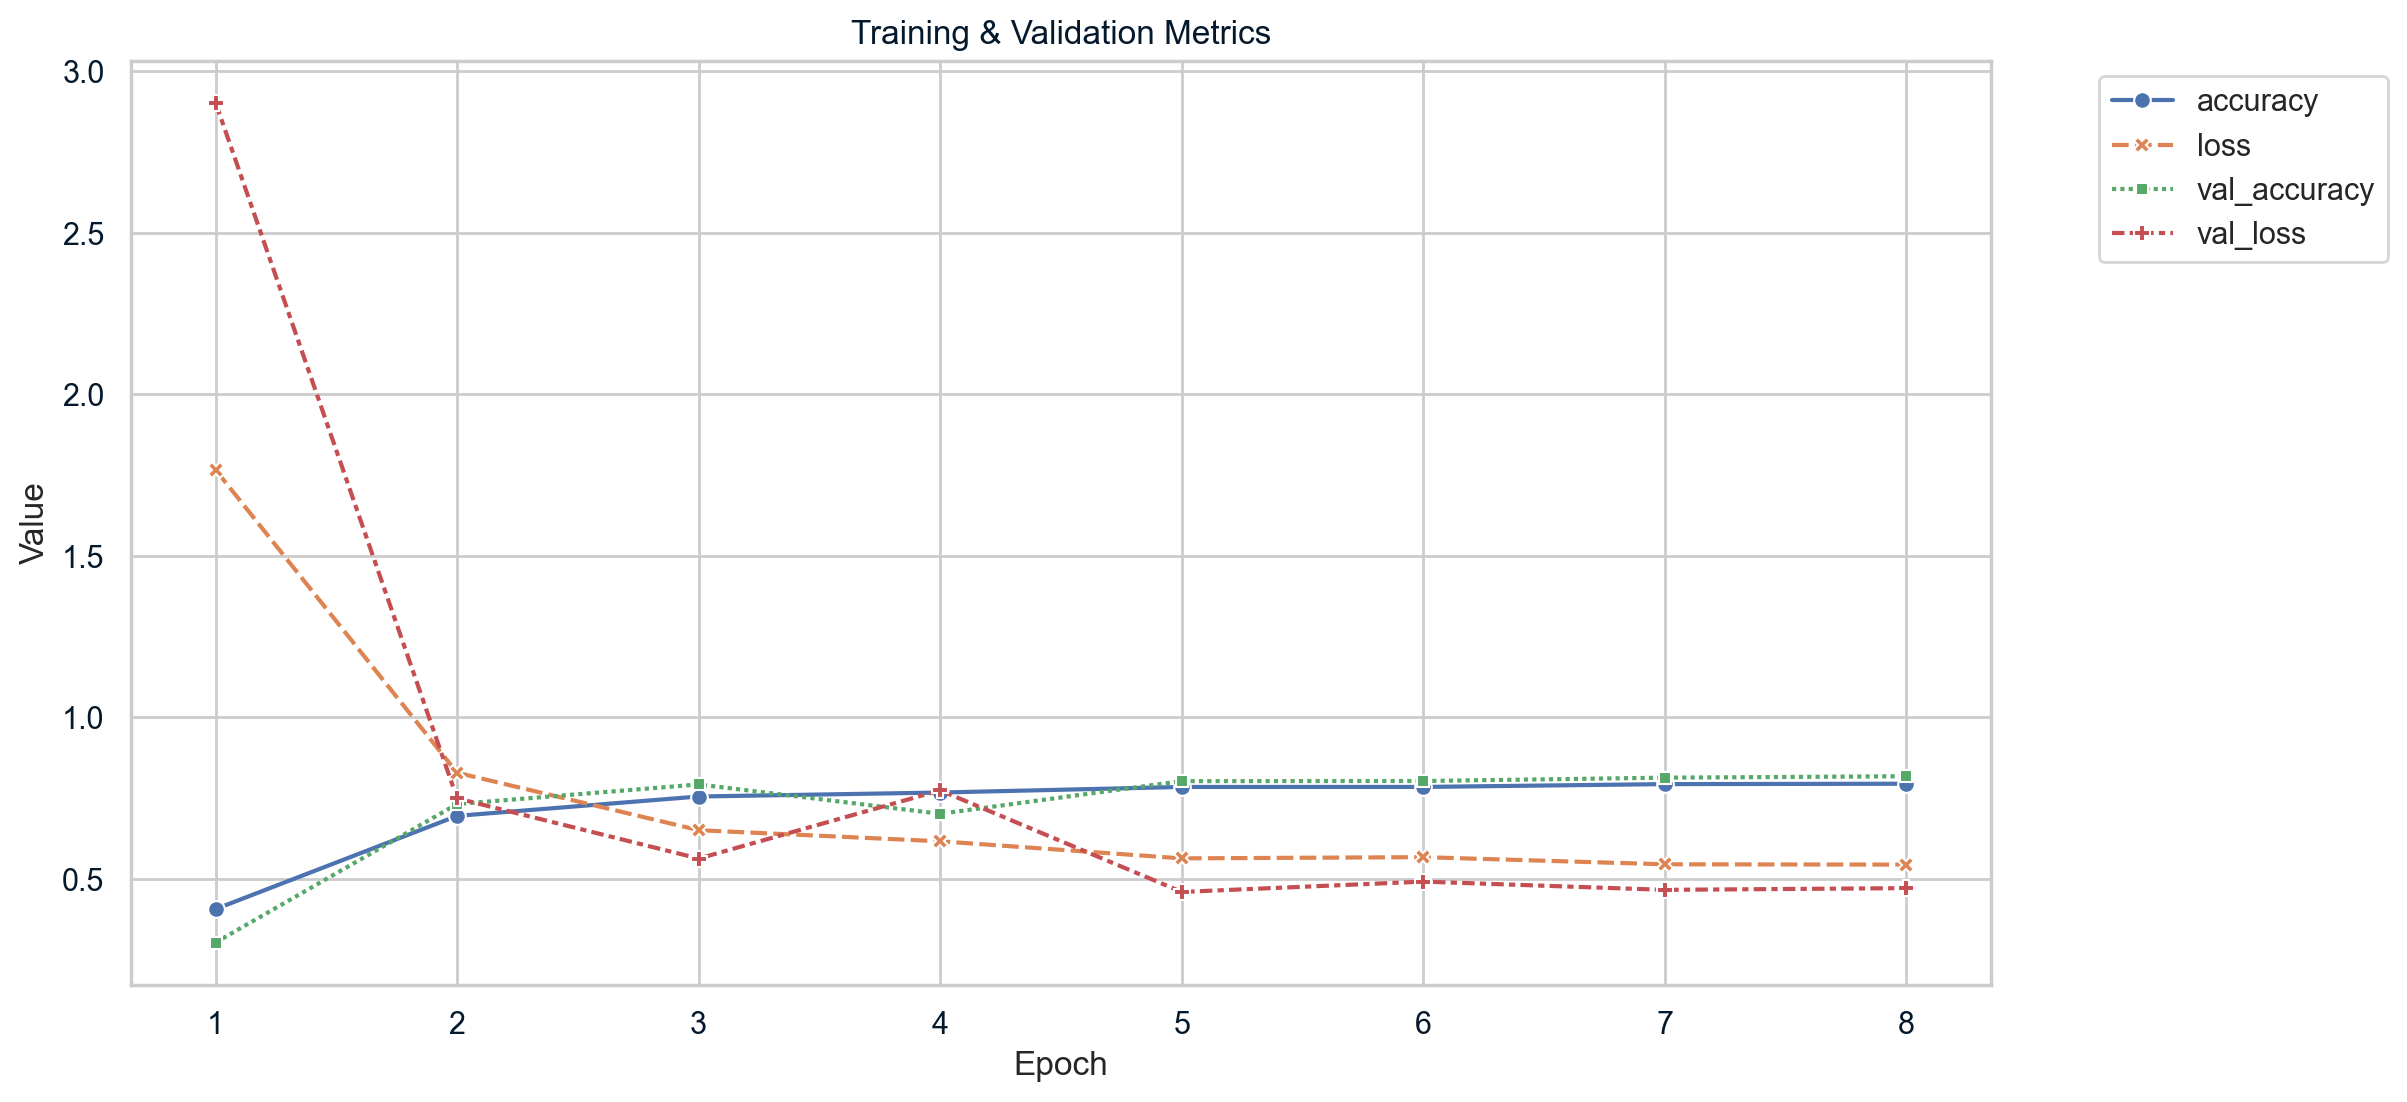

[0.40641292929649353, 0.694884181022644, 0.7548911571502686, 0.7671806812286377, 0.7844624519348145, 0.7845178842544556, 0.7932557463645935, 0.7944192886352539]


In [86]:
#check above 

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=melted_df, x='epoch', y='value', hue='metric', style='metric', markers=True)
plt.title('Training & Validation Metrics')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



#we take last one which is ~79% with 54% loss

print(history.history['accuracy'])

In [87]:
#wow its pretty low so I decided to redo it but put a LOT more because it might be underfit

model = Sequential([
    Dense(256, activation='relu', input_shape=(59,)),
    BatchNormalization(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(13, activation='softmax') 
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',  # Changed from 'sparse_categorical_crossentropy' to 'categorical_crossentropy'
    metrics=['accuracy']
)

#early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3)

# Assuming train_y is one-hot encoded
history = model.fit(train_X, train_y, epochs=50, batch_size=256,  validation_split=0.2, callbacks=[early_stop])

# Convert history to DataFrame for Seaborn
history_df = pd.DataFrame(history.history)
history_df['epoch'] = history_df.index + 1

# Melt for Seaborn
melted_df = history_df.melt(id_vars='epoch', var_name='metric', value_name='value')




Epoch 1/50
705/705 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.2345 - loss: 2.3566 - val_accuracy: 0.2058 - val_loss: 3.3099
Epoch 2/50
705/705 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7038 - loss: 0.8143 - val_accuracy: 0.2358 - val_loss: 6.0822
Epoch 3/50
705/705 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.7872 - loss: 0.5555 - val_accuracy: 0.2120 - val_loss: 15.6974
Epoch 4/50
705/705 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.7990 - loss: 0.5260 - val_accuracy: 0.2025 - val_loss: 30.3605


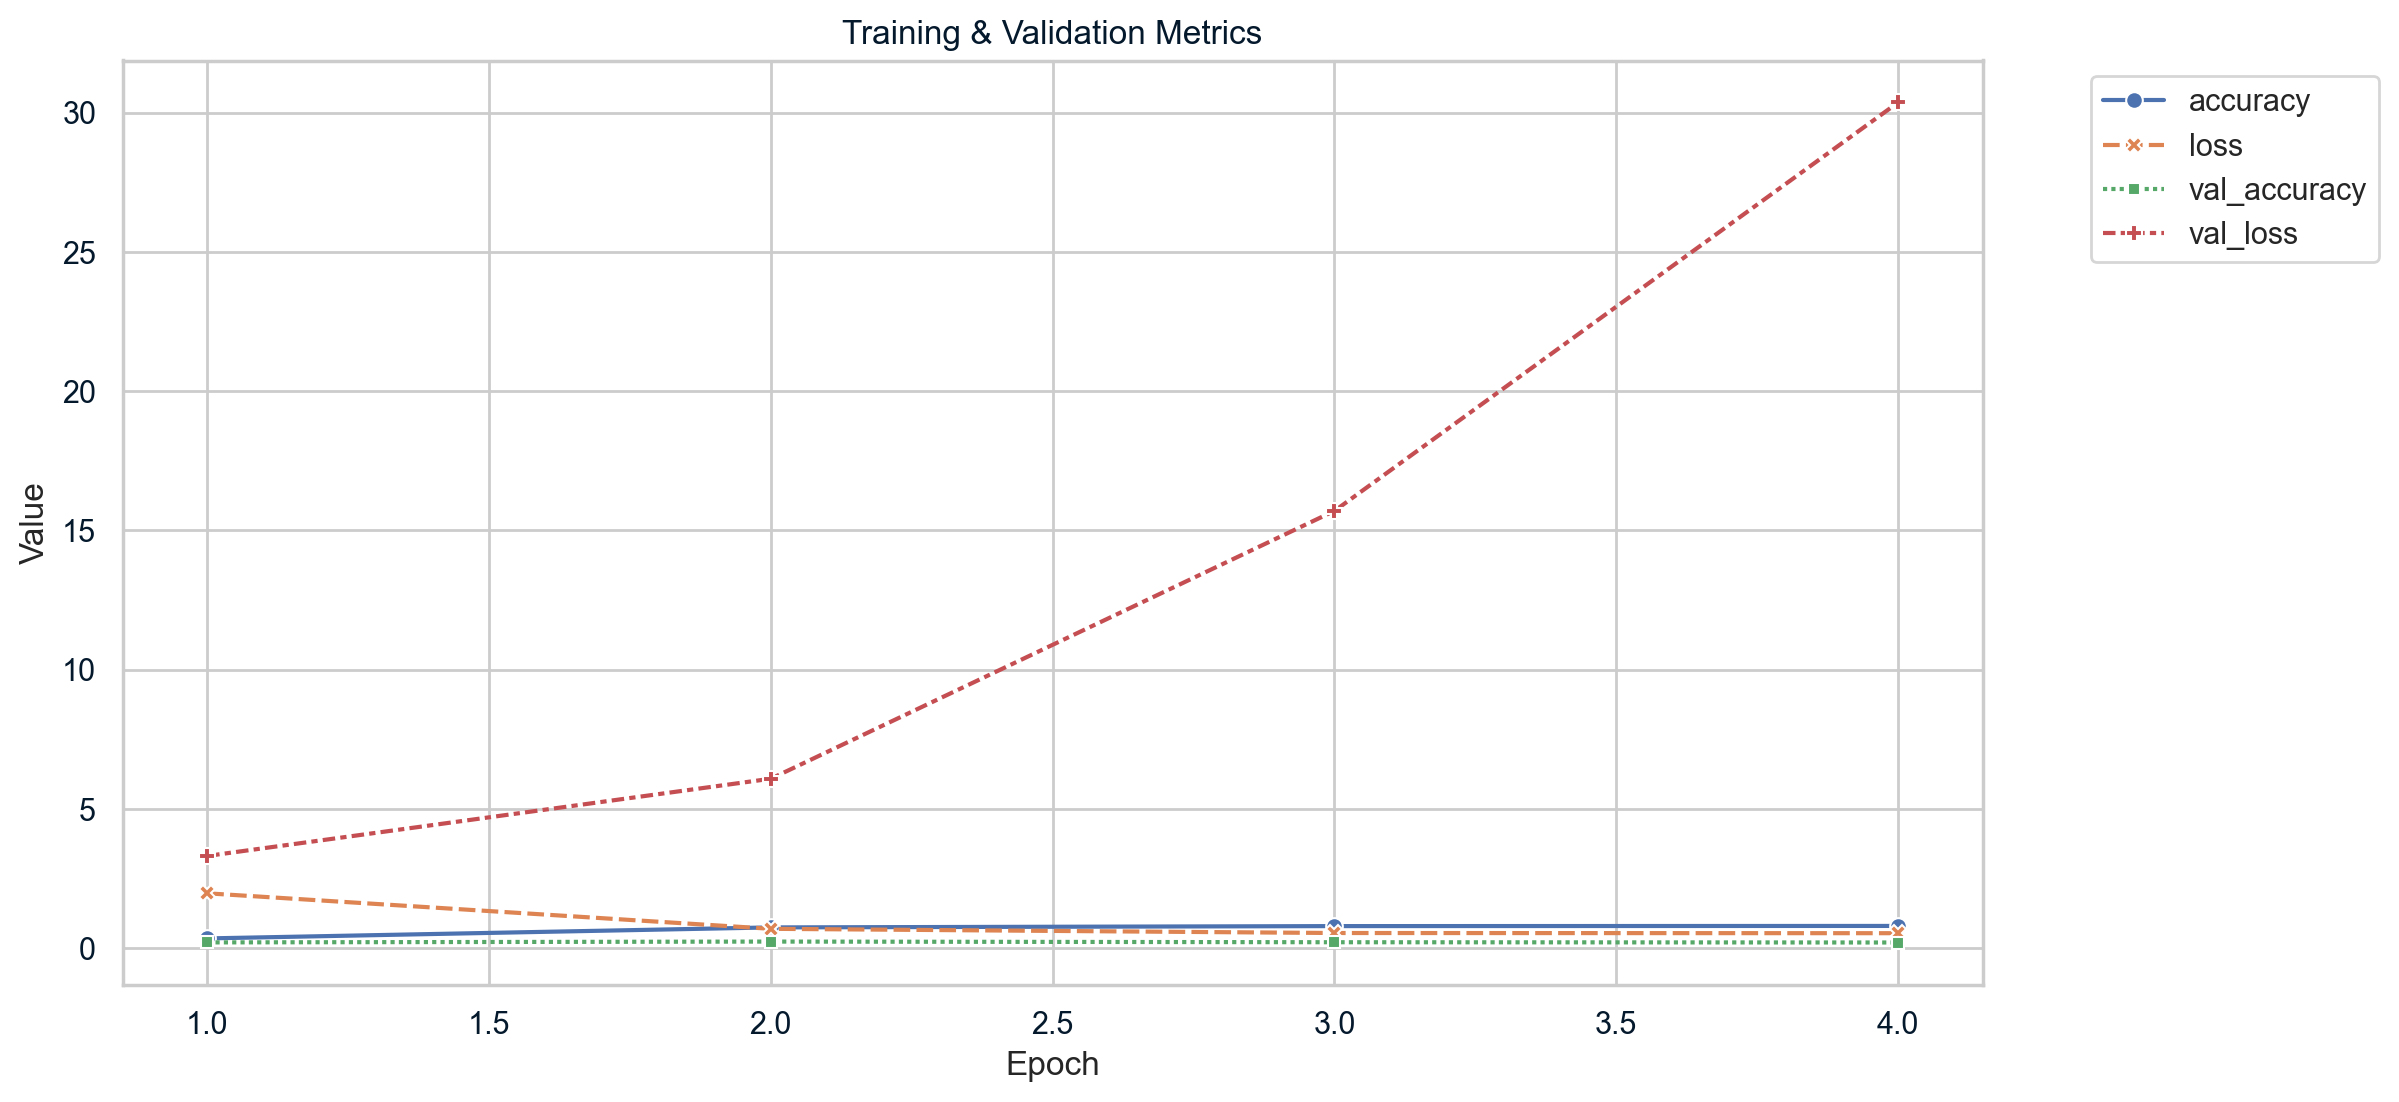

[0.34868323802948, 0.7442195415496826, 0.791244387626648, 0.7971619963645935]


In [88]:
#check above 

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=melted_df, x='epoch', y='value', hue='metric', style='metric', markers=True)
plt.title('Training & Validation Metrics')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

print(history.history['accuracy'])

#we take last one which is about the same but better - 80% accuracy 52% loss

Final:

Random Forest: ~81% accuracy 
XG boost: ~80% accuracy 
Descision Tree: ~79% accuracy
Neural Network: ~79% accuracy
Updates NN (after tuned): ~80% accuracy

It seems that they are mostly the same.

This is different from what I originally thought, which I thought descision tree would be worst and it would go up to neural network would be best by far, but it turns out that all are really close.  

Overall, it seems Neural Networks might be best, especially for large datasets because they are most easily scaled (you can add more layers easily), while descision trees and related just get slower and have diminishing returns. 

The NN was at one point 57% but I learned that it was underfitted and trained it more deeply, and it resolved to 80% which is good.

A comparison might be an engine, where Descision tree and related are stock vs Neural Networks are highly customizable, tuned cars that can be precisely tuned or jacked up extremely.

There are many use cases, but one I think is best is when there is a situation, there are details such as beat, time, date, etc but the exact situation might not be clear. This AI could give a prediction that could help police officers a chance to prepare, e.g have swat on standby if it's terrorist, or bring dogs for drugs, etc. Even if its incorrect, an 80% chance is still pretty good and preperation doesent hurt.